## Modeling Phase

With the dataset cleaned and prepared, the next step is to build and evaluate classification models to predict wine quality.

Given the class imbalance identified during the exploratory analysis, model evaluation goes beyond standard metrics such as accuracy. Instead, the focus is placed on metrics that better reflect the impact of different types of prediction errors.

In particular, a cost-sensitive approach is adopted, where false positives carry a significantly higher penalty than other types of errors. This makes precision a critical metric in the modeling process.

Additionally, predicted probabilities are used to adjust the classification threshold, allowing model decisions to be aligned with the defined cost structure and business objective of maximizing profit.

In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score

In [91]:
data = pd.read_csv("wine_clean_data.csv")

### Train-Test Split

Before training the models, the dataset is split into training and testing sets.

A stratified split is used to preserve the original class distribution, ensuring that both sets maintain the imbalance observed during the exploratory analysis. This is critical to obtain reliable and comparable performance metrics.

The target variable is also encoded into a binary format:
- 1 → High quality (Premium)
- 0 → Low quality (Normal)

In [92]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = data.drop(columns=['quality', 'quality_label'])
y = data['quality_label']

# Labeling before the division: 'Low' -> 0, 'High' -> 1
y = y.map({'Low': 0, 'High': 1})

# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [93]:
# Compare class proportions between train and test sets
print("Train Test Split\n")

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

print("\nClass distribution")

summary = pd.DataFrame({
    'Train (%)': (y_train.value_counts(normalize=True)*100).round(2),
    'Test (%)': (y_test.value_counts(normalize=True)*100).round(2)
})

print(summary)

Train Test Split

Train size: (3248, 12)
Test size: (1392, 12)

Class distribution
               Train (%)  Test (%)
quality_label                     
0                  78.33      78.3
1                  21.67      21.7


The results confirm that the stratified split successfully preserved the original class distribution, with approximately 78% Low quality wines and 22% High quality wines in both training and testing sets.

This consistency enables a fair comparison of model performance and is especially important when evaluating models using cost-sensitive metrics such as profit, where class proportions directly influence the final outcome.

## Models

### Logistic Regression

Logistic Regression is used as the first benchmark model in the classification stage.

It provides a strong and interpretable baseline, allowing us to understand how key features influence the probability of a wine being classified as High quality.

While relatively simple, this model serves as a reference point for evaluating whether more complex models can deliver meaningful improvements in performance and business impact.

In [94]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

To improve baseline performance, hyperparameter tuning is applied using GridSearchCV with Stratified K-Fold cross-validation.

Precision is selected as the optimization metric at this stage because false positives carry the highest penalty in the business cost structure. This makes it more important to control incorrect High quality predictions than to maximize overall accuracy.

In [95]:
# Hyperparameter grid
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__class_weight': ['balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline_lr,
    param_grid,
    cv=cv,
    scoring='precision',
    n_jobs=-1
)

grid.fit(X_train, y_train)

c:\Users\Usuario\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': ['balanced'], 'model__penalty': ['l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [96]:
# Extracting fold scores for the best parameter combination
cv_results = grid.cv_results_
best_index = grid.best_index_

fold_scores = [
    cv_results[f'split{i}_test_score'][best_index]
    for i in range(cv.get_n_splits())
]

print("Best params:", grid.best_params_)
print("Fold scores:", [f"{score:.4f}" for score in fold_scores])
print(f"Best CV Precision: {grid.best_score_:.4f}")
print(f"Mean CV Precision: {cv_results['mean_test_score'][grid.best_index_]:.4f}")
print(f"Std CV Precision: {cv_results['std_test_score'][grid.best_index_]:.4f}")

Best params: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l2'}
Fold scores: ['0.3793', '0.4280', '0.4173', '0.3846', '0.4120']
Best CV Precision: 0.4043
Mean CV Precision: 0.4043
Std CV Precision: 0.0190


The best-performing configuration achieved a mean cross-validated precision of approximately 0.40, with low variability across folds.

This indicates that the model delivers stable precision performance, although the absolute value suggests there is room for improvement in controlling false positives. This makes Logistic Regression a useful baseline, but not necessarily the optimal solution for the problem.

After selecting the best hyperparameter combination, the model is evaluated on the test set.

As this model serves only as a baseline, no threshold optimization is applied.
The model is evaluated using a fixed threshold of 0.65 to make predictions
more conservative and reduce false positives, without the systematic optimization
applied to the ensemble models.

In [97]:
best_model = grid.best_estimator_

y_pred_lr = best_model.predict(X_test)
y_proba_lr = best_model.predict_proba(X_test)[:, 1]

# Increase the decision threshold to reduce false positives
threshold_lr = 0.65
y_pred_lr_mod = (y_proba_lr >= threshold_lr).astype(int)

acc_lr = accuracy_score(y_test, y_pred_lr_mod)
precision_lr = precision_score(y_test, y_pred_lr_mod)
cm_lr = confusion_matrix(y_test, y_pred_lr_mod)
report_lr = classification_report(y_test, y_pred_lr_mod, target_names=['Low', 'High'], digits=4)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"Logistic Regression (threshold = {threshold_lr})")
print(f"Accuracy test: {acc_lr:.4f}")
print(f"ROC AUC: {auc_lr:.4f}")
print(f"Precision: {precision_lr:.4f}\n")
print("Classification report:")
print(report_lr)
print("Confusion Matrix:")
print(cm_lr)

Logistic Regression (threshold = 0.65)
Accuracy test: 0.8082
ROC AUC: 0.8123
Precision: 0.5651

Classification report:
              precision    recall  f1-score   support

         Low     0.8664    0.8927    0.8793      1090
        High     0.5651    0.5033    0.5324       302

    accuracy                         0.8082      1392
   macro avg     0.7157    0.6980    0.7059      1392
weighted avg     0.8010    0.8082    0.8041      1392

Confusion Matrix:
[[973 117]
 [150 152]]


The test results show that Logistic Regression achieves a solid ROC AUC, indicating good ranking ability between Low and High quality wines.

After increasing the threshold to 0.65, the model becomes more selective when predicting the High quality class, improving precision and aligning with the objective of reducing costly false positives. However, this comes at the cost of lower recall, meaning that some truly High quality wines are not identified.

The ROC curve is used to evaluate the model's ability to separate both classes across all possible classification thresholds.

This provides a threshold-independent view of performance and complements the threshold-specific evaluation used for business decision-making.

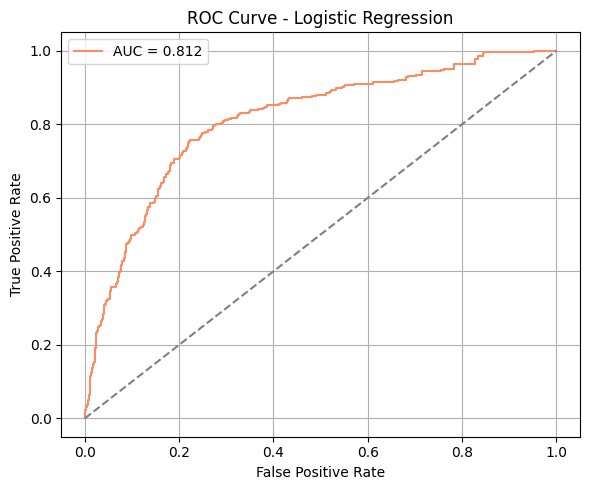

In [98]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f'AUC = {auc_lr:.3f}', color='#FC8D62')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.grid(True)

The ROC curve confirms that the model has a reasonable ability to distinguish between Low and High quality wines, with an AUC above 0.80.

However, while ROC AUC reflects good overall discrimination, it does not fully capture the business impact of prediction errors.

While these results are consistent with the business objective, the trade-off highlights potential limitations of a linear model.  More flexible models may be able to achieve a better balance between precision and recall, improving overall business performance.

### Random Forest

Random Forest is introduced as a more flexible alternative to Logistic Regression, capable of capturing non-linear relationships and complex interactions between variables.

Since tree-based models are not sensitive to feature scale, no standardization step is required in this case.

In [99]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

As in the previous model, hyperparameter tuning is applied using GridSearchCV with Stratified K-Fold cross-validation and precision is used as the optimization metric in order to reduce false positive predictions, which represent the highest cost in the business cost matrix.

In [100]:
# Hyperparameter grid
param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5],
    'model__class_weight': ['balanced']
}

cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=cv_rf,
    scoring='precision',
)

grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced'], 'model__max_depth': [None, 10], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more mess

In [101]:
cv_results_rf = grid_rf.cv_results_
best_index_rf = grid_rf.best_index_

fold_scores_rf = [
    cv_results_rf[f'split{i}_test_score'][best_index_rf]
    for i in range(cv_rf.get_n_splits())
]

print("Best params:", grid_rf.best_params_)
print("Fold scores:", [f"{score:.4f}" for score in fold_scores_rf])

print(f"Best CV Precision: {grid_rf.best_score_:.4f}")

print(f"Mean CV Precision: {cv_results_rf['mean_test_score'][grid_rf.best_index_]:.4f}")
print(f"Std CV Precision: {cv_results_rf['std_test_score'][grid_rf.best_index_]:.4f}")

Best params: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Fold scores: ['0.8022', '0.7831', '0.7561', '0.7500', '0.7805']
Best CV Precision: 0.7744
Mean CV Precision: 0.7744
Std CV Precision: 0.0191


The best Random Forest configuration achieved a mean cross-validated precision of approximately 0.77, with low variability across folds.

This represents a substantial improvement over Logistic Regression, suggesting that the model is better able to control false positives while maintaining stable performance across training folds.

These results indicate that allowing for non-linear decision boundaries adds meaningful predictive value in this classification problem.

The model is first evaluated using the default classification threshold of 0.5 to establish a baseline performance before any threshold optimization.

In [102]:
best_model_rf = grid_rf.best_estimator_

y_proba_rf = best_model_rf.predict_proba(X_test)[:, 1]
y_pred_rf_default = (y_proba_rf >= 0.5).astype(int)

acc_rf_default = accuracy_score(y_test, y_pred_rf_default)
precision_rf_default = precision_score(y_test, y_pred_rf_default)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Random Forest (threshold = 0.5)")
print(f"Accuracy: {acc_rf_default:.4f}")
print(f"ROC AUC: {auc_rf:.4f}")
print(f"Precision: {precision_rf_default:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf_default, target_names=['Low', 'High'], digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_default))

Random Forest (threshold = 0.5)
Accuracy: 0.8843
ROC AUC: 0.9312
Precision: 0.8406

Classification Report:
              precision    recall  f1-score   support

         Low     0.8920    0.9697    0.9292      1090
        High     0.8406    0.5762    0.6837       302

    accuracy                         0.8843      1392
   macro avg     0.8663    0.7729    0.8065      1392
weighted avg     0.8808    0.8843    0.8760      1392

Confusion Matrix:
[[1057   33]
 [ 128  174]]


Random Forest delivers a clear improvement over Logistic Regression on the test set.

The model achieves substantially higher precision and ROC AUC, while also improving overall accuracy. This indicates a stronger ability to distinguish between Low and High quality wines and to make more reliable positive predictions.

At this stage, Random Forest appears to offer a better balance between predictive performance and business impact than the baseline model.

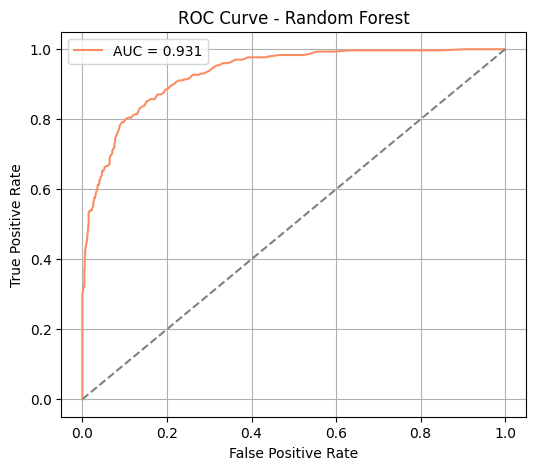

In [103]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f'AUC = {auc_rf:.3f}', color='#FC8D62')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(True)

The ROC curve confirms the strong discriminative ability of Random Forest, with an AUC above 0.93.

This indicates that the model is highly effective at ranking wines.

However, we are evaluating business impact rather than model global efficency, so rather than relying on the default threshold, the classification threshold is optimized to maximize business profit under the defined cost structure. The curve below shows how profit varies across different threshold values.

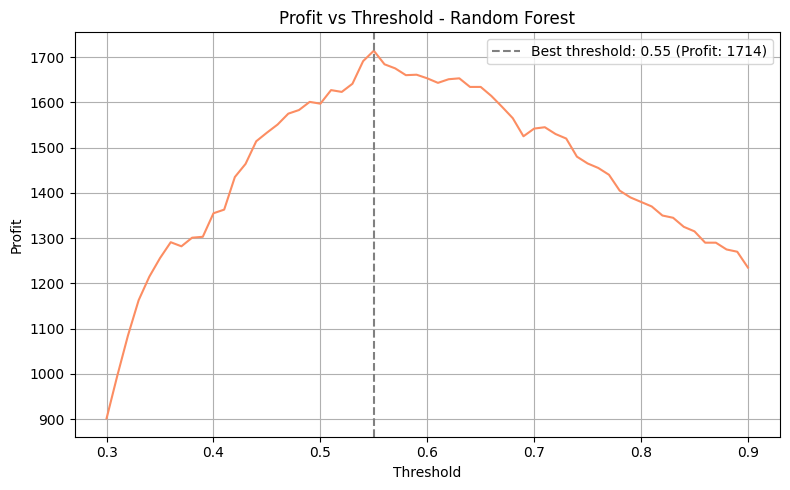

Best threshold: 0.55
Best profit: 1714


In [104]:
cost_values = {
    'TP': 5,
    'TN': 1,
    'FP': -10,
    'FN': 0
}

thresholds = np.arange(0.3, 0.9, 0.01)
profits_rf = []

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    profit = (
        tp * cost_values['TP'] +
        tn * cost_values['TN'] +
        fp * cost_values['FP'] +
        fn * cost_values['FN']
    )
    profits_rf.append(profit)

best_threshold_rf = thresholds[np.argmax(profits_rf)]
best_profit_rf = max(profits_rf)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, profits_rf, color='#FC8D62')
plt.axvline(best_threshold_rf, color="grey", linestyle='--',
            label=f'Best threshold: {best_threshold_rf:.2f} (Profit: {best_profit_rf})')
plt.xlabel('Threshold')
plt.ylabel('Profit')
plt.title('Profit vs Threshold - Random Forest')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Best threshold: {best_threshold_rf:.2f}")
print(f"Best profit: {best_profit_rf}")

Using the threshold identified above, the model is re-evaluated to obtain the final performance metrics aligned with the business objective.

In [105]:
y_pred_rf_opt = (y_proba_rf >= best_threshold_rf).astype(int)

acc_rf_opt = accuracy_score(y_test, y_pred_rf_opt)
precision_rf_opt = precision_score(y_test, y_pred_rf_opt)
cm_rf = confusion_matrix(y_test, y_pred_rf_opt)

print(f"Random Forest (threshold = {best_threshold_rf:.2f})")
print(f"Accuracy: {acc_rf_opt:.4f}")
print(f"ROC AUC: {auc_rf:.4f}")
print(f"Precision: {precision_rf_opt:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf_opt, target_names=['Low', 'High'], digits=4))
print("Confusion Matrix:")
print(cm_rf)

Random Forest (threshold = 0.55)
Accuracy: 0.8865
ROC AUC: 0.9312
Precision: 0.9091

Classification Report:
              precision    recall  f1-score   support

         Low     0.8832    0.9853    0.9315      1090
        High     0.9091    0.5298    0.6695       302

    accuracy                         0.8865      1392
   macro avg     0.8962    0.7576    0.8005      1392
weighted avg     0.8888    0.8865    0.8746      1392

Confusion Matrix:
[[1074   16]
 [ 142  160]]


### XGBoost

At last, XGBoost is evaluated as a more advanced ensemble model to determine whether boosting can further improve performance over Random Forest.

Compared with the previous models, XGBoost may provide a stronger balance between flexibility, predictive power, and control over classification errors, making it a strong candidate for the final comparison.

In [106]:
from xgboost import XGBClassifier

pipeline_xgb = Pipeline([
    ('model', XGBClassifier(random_state=42))
])

In [107]:
# Hyperparameter grid
param_grid_xgb = {
    'model__n_estimators': [150, 200, 250],
    'model__max_depth': [3, 6, 9],
    'model__learning_rate': [0.1, 0.2],
    'model__subsample': [0.8, 1.0]
}

cv_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    pipeline_xgb,
    param_grid_xgb,
    cv=cv_xgb,
    scoring='precision',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.1, 0.2], 'model__max_depth': [3, 6, ...], 'model__n_estimators': [150, 200, ...], 'model__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages

In [108]:
cv_results_xgb = grid_xgb.cv_results_
best_index_xgb = grid_xgb.best_index_

fold_scores_xgb = [
    cv_results_xgb[f'split{i}_test_score'][best_index_xgb]
    for i in range(cv_xgb.get_n_splits())
]

print("Best params:", grid_xgb.best_params_)
print("Fold scores:", [f"{score:.4f}" for score in fold_scores_xgb])

print(f"Best CV Precision: {grid_xgb.best_score_:.4f}")

print(f"Mean CV Precision: {cv_results_xgb['mean_test_score'][grid_xgb.best_index_]:.4f}")
print(f"Std CV Precision: {cv_results_xgb['std_test_score'][grid_xgb.best_index_]:.4f}")

Best params: {'model__learning_rate': 0.1, 'model__max_depth': 9, 'model__n_estimators': 150, 'model__subsample': 0.8}
Fold scores: ['0.7864', '0.7228', '0.6930', '0.7131', '0.7059']
Best CV Precision: 0.7242
Mean CV Precision: 0.7242
Std CV Precision: 0.0326


The best XGBoost configuration achieved a mean cross-validated precision of approximately 0.71, with very low variability across folds.

This indicates stable performance and strong control over false positives, although the cross-validated precision remains below the level achieved by Random Forest. At this stage, XGBoost appears competitive, but not clearly superior to the strongest model so far.

The model is first evaluated using the default classification threshold of 0.5 to establish a baseline performance before any threshold optimization.

In [109]:
best_model_xgb = grid_xgb.best_estimator_

y_proba_xgb = best_model_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb_default = (y_proba_xgb >= 0.5).astype(int)

acc_xgb_default = accuracy_score(y_test, y_pred_xgb_default)
precision_xgb_default = precision_score(y_test, y_pred_xgb_default)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"XGBoost (threshold = 0.5)")
print(f"Accuracy: {acc_xgb_default:.4f}")
print(f"ROC AUC: {auc_xgb:.4f}")
print(f"Precision: {precision_xgb_default:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb_default, target_names=['Low', 'High'], digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_default))

XGBoost (threshold = 0.5)
Accuracy: 0.8793
ROC AUC: 0.9185
Precision: 0.7839

Classification Report:
              precision    recall  f1-score   support

         Low     0.8988    0.9532    0.9252      1090
        High     0.7839    0.6126    0.6877       302

    accuracy                         0.8793      1392
   macro avg     0.8413    0.7829    0.8065      1392
weighted avg     0.8739    0.8793    0.8737      1392

Confusion Matrix:
[[1039   51]
 [ 117  185]]


With the default threshold applied, XGBoost already shows strong performance, achieving a ROC AUC above 0.91. The ROC curve below confirms its ability to separate both classes across all possible thresholds.

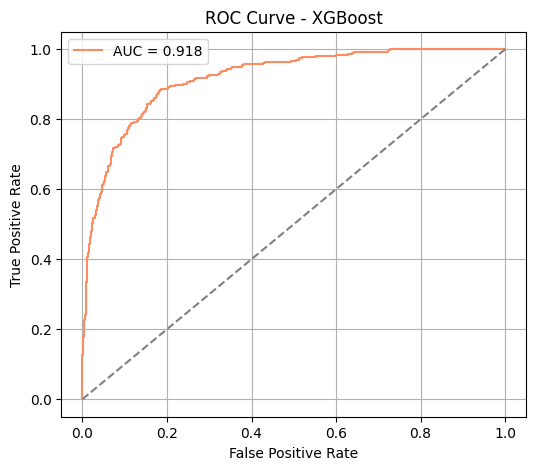

In [110]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label=f'AUC = {auc_xgb:.3f}', color='#FC8D62')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid(True)

Rather than relying on the default threshold, the classification threshold is optimized to maximize business profit under the defined cost structure. The curve below shows how profit varies across different threshold values.

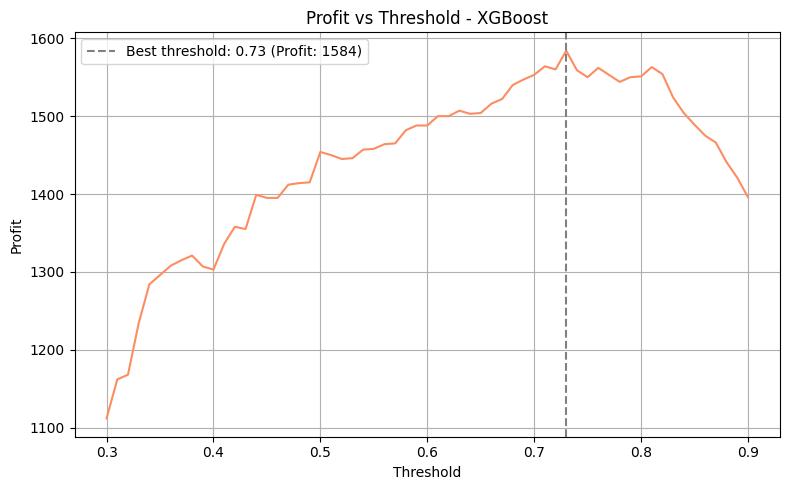

Best threshold: 0.73
Best profit: 1584


In [111]:
profits_xgb = []

for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    profit = (
        tp * cost_values['TP'] +
        tn * cost_values['TN'] +
        fp * cost_values['FP'] +
        fn * cost_values['FN']
    )
    profits_xgb.append(profit)

best_threshold_xgb = thresholds[np.argmax(profits_xgb)]
best_profit_xgb = max(profits_xgb)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, profits_xgb, color='#FC8D62')
plt.axvline(best_threshold_xgb, color="grey", linestyle='--',
            label=f'Best threshold: {best_threshold_xgb:.2f} (Profit: {best_profit_xgb})')
plt.xlabel('Threshold')
plt.ylabel('Profit')
plt.title('Profit vs Threshold - XGBoost')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('profit_threshold_xgb.png')
plt.show()

print(f"Best threshold: {best_threshold_xgb:.2f}")
print(f"Best profit: {best_profit_xgb}")

Using the threshold identified above, the model is re-evaluated to obtain the final
performance metrics aligned with the business objective.

In [112]:
y_pred_xgb_opt = (y_proba_xgb >= best_threshold_xgb).astype(int)

acc_xgb_opt = accuracy_score(y_test, y_pred_xgb_opt)
precision_xgb_opt = precision_score(y_test, y_pred_xgb_opt)
cm_xgb = confusion_matrix(y_test, y_pred_xgb_opt)

print(f"XGBoost (threshold = {best_threshold_xgb:.2f})")
print(f"Accuracy: {acc_xgb_opt:.4f}")
print(f"ROC AUC: {auc_xgb:.4f}")
print(f"Precision: {precision_xgb_opt:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb_opt, target_names=['Low', 'High'], digits=4))
print("Confusion Matrix:")
print(cm_xgb)

XGBoost (threshold = 0.73)
Accuracy: 0.8721
ROC AUC: 0.9185
Precision: 0.8735

Classification Report:
              precision    recall  f1-score   support

         Low     0.8719    0.9807    0.9231      1090
        High     0.8735    0.4801    0.6197       302

    accuracy                         0.8721      1392
   macro avg     0.8727    0.7304    0.7714      1392
weighted avg     0.8723    0.8721    0.8573      1392

Confusion Matrix:
[[1069   21]
 [ 157  145]]


## Model Performance Comparison

To compare the models, their performance is evaluated using multiple classification metrics.

While several metrics are reported, special attention is given to precision and PR AUC, as they are more aligned with the business objective of minimizing costly false positive predictions.

This comparison provides a technical perspective on model performance before incorporating cost-sensitive evaluation.

In [113]:
from sklearn.metrics import recall_score, f1_score, average_precision_score, precision_recall_curve

models_dict = {
    'Logistic Regression': {
        'y_pred': y_pred_lr_mod,
        'y_proba': y_proba_lr,
        'name': 'LR'
    },
    'Random Forest': {
        'y_pred': y_pred_rf_opt,
        'y_proba': y_proba_rf,
        'name': 'RF'
    },
    'XGBoost': {
        'y_pred': y_pred_xgb_opt,
        'y_proba': y_proba_xgb,
        'name': 'XGB'
    }
}

# Compute evaluation metrics for each model
metrics_comparison = []

for model_name, model_data in models_dict.items():
    y_pred = model_data['y_pred']
    y_proba = model_data['y_proba']
    
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    metrics_comparison.append({
        'Model': model_name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'PR AUC': pr_auc,
        'ROC AUC': roc_auc
    })

df_metrics = pd.DataFrame(metrics_comparison)
df_metrics = df_metrics.set_index('Model')

print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
print(df_metrics.round(4))
print()

MODEL PERFORMANCE COMPARISON
                     Precision  Recall  F1-Score  PR AUC  ROC AUC
Model                                                            
Logistic Regression     0.5651  0.5033    0.5324  0.5528   0.8123
Random Forest           0.9091  0.5298    0.6695  0.8287   0.9312
XGBoost                 0.8735  0.4801    0.6197  0.7916   0.9185



The results show a clear performance gap between Logistic Regression and the ensemble models.

Random Forest achieves the highest precision, indicating a strong ability to avoid false positive predictions. It also leads in PR AUC and ROC AUC, suggesting superior performance both in terms of positive class detection and overall class separation.

XGBoost performs significantly better than Logistic Regression and remains competitive, but it does not surpass Random Forest in the key metrics most relevant to this problem.

These results suggest that Random Forest is currently the strongest candidate from a predictive performance standpoint. However, final model selection should still consider the business cost structure to determine which model delivers the highest overall value.

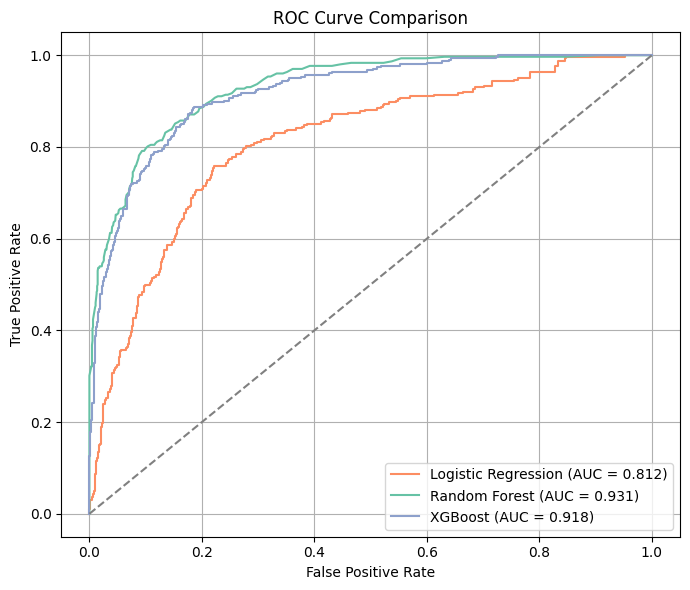

In [114]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(7, 6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='#FC8D62')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='#66C2A5')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', color='#8DA0CB')

plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_comparison.png")
plt.show()

## Cost-Sensitive Evaluation

To evaluate the models from a business perspective, confusion matrices are analyzed for each model.

These values allow us to quantify the number of true positives, false positives, true negatives, and false negatives, which are directly linked to the defined cost structure.

In [115]:
profit_records = []

for model_name, model_data in models_dict.items():
    y_pred = model_data['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    profit_records.append({
        'Model': model_name,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
    })

    print(f"{model_name}:")
    print(f"  TN: {tn}, FP: {fp}")
    print(f"  FN: {fn}, TP: {tp}")
    print()



Logistic Regression:
  TN: 973, FP: 117
  FN: 150, TP: 152

Random Forest:
  TN: 1074, FP: 16
  FN: 142, TP: 160

XGBoost:
  TN: 1069, FP: 21
  FN: 157, TP: 145



The confusion matrices reveal clear differences in how each model handles classification errors.

Random Forest produces a very low number of false positives, which is critical given the high cost associated with this type of error. XGBoost, while identifying more true positives, generates more false positives, reducing its overall business value. Logistic Regression shows the weakest performance, with both higher false positives and fewer true positives.

These differences highlight the importance of evaluating models not only through aggregated metrics, but also through their error distribution.

To determine the real business impact of each model, a cost-based evaluation is applied using the predefined cost matrix:

- True Positive: +5  
- True Negative: +1  
- False Positive: -10  
- False Negative: 0  

Using these values, the total profit generated by each model is calculated based on its confusion matrix.

In [116]:
df_profit = pd.DataFrame(profit_records).set_index('Model')

# Multiply each column by its cost value to see the real contribution
cost_multiplier = pd.Series({
    'TN': cost_values['TN'],
    'FP': cost_values['FP'],
    'FN': cost_values['FN'],
    'TP': cost_values['TP']
})
df_profit_contribution = df_profit[['TN', 'FP', 'FN', 'TP']].mul(cost_multiplier, axis=1)
df_profit_contribution['Profit'] = df_profit_contribution.sum(axis=1)

print('=' * 80)
print('PROFIT COMPARISON BY MODEL (COUNTS)')
print('=' * 80)
print(df_profit)
print()
print('=' * 80)
print('PROFIT COMPARISON BY MODEL (COST CONTRIBUTIONS)')
print('=' * 80)
print(df_profit_contribution)
print()

PROFIT COMPARISON BY MODEL (COUNTS)
                       TN   FP   FN   TP
Model                                   
Logistic Regression   973  117  150  152
Random Forest        1074   16  142  160
XGBoost              1069   21  157  145

PROFIT COMPARISON BY MODEL (COST CONTRIBUTIONS)
                       TN    FP  FN   TP  Profit
Model                                           
Logistic Regression   973 -1170   0  760     563
Random Forest        1074  -160   0  800    1714
XGBoost              1069  -210   0  725    1584



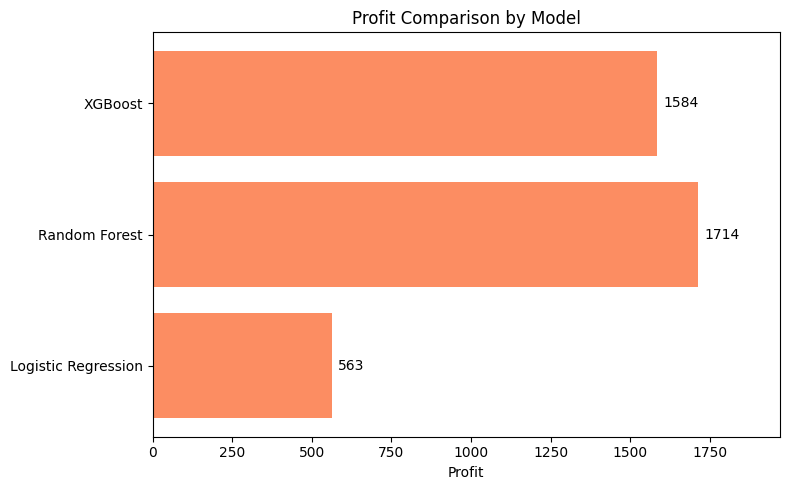

In [117]:
models = df_profit_contribution.index.tolist()
values = df_profit_contribution['Profit'].tolist()

plt.figure(figsize=(8, 5))
plt.barh(models, values, color='#FC8D62')
plt.xlabel("Profit")
plt.title("Profit Comparison by Model")
plt.xlim(0, max(values) * 1.15)


for i, v in enumerate(values):
    plt.text(v + 20, i, str(v), va='center')

plt.tight_layout()
plt.savefig("profit_chart.png")
plt.show()

Random Forest generates the highest profit of the three models evaluated. Compared to XGBoost, it delivers approximately 17% more profit, while outperforming Logistic Regression by more than 3x. This gap is primarily explained by Random Forest's ability to minimize false positives, which carry the highest penalty (-10) in the defined cost structure.

Although XGBoost identifies more true positives, the additional false positives reduce its overall profitability. Logistic Regression performs the worst, as it fails to adequately control costly errors.

These results confirm that the model with the best predictive metrics is not necessarily the one that maximizes business value. In this case, Random Forest provides the best balance between prediction quality and cost efficiency.

This analysis highlights the importance of aligning model evaluation with business objectives. Optimizing traditional metrics alone would not have been sufficient to identify the most valuable model in this context.

### Feature Importance

As Random Forest was selected as the best model, its feature importance scores
are analyzed to understand which variables contributed most to the classification
decisions.

This provides interpretability to the model and connects back to the relationships
identified during the exploratory analysis.

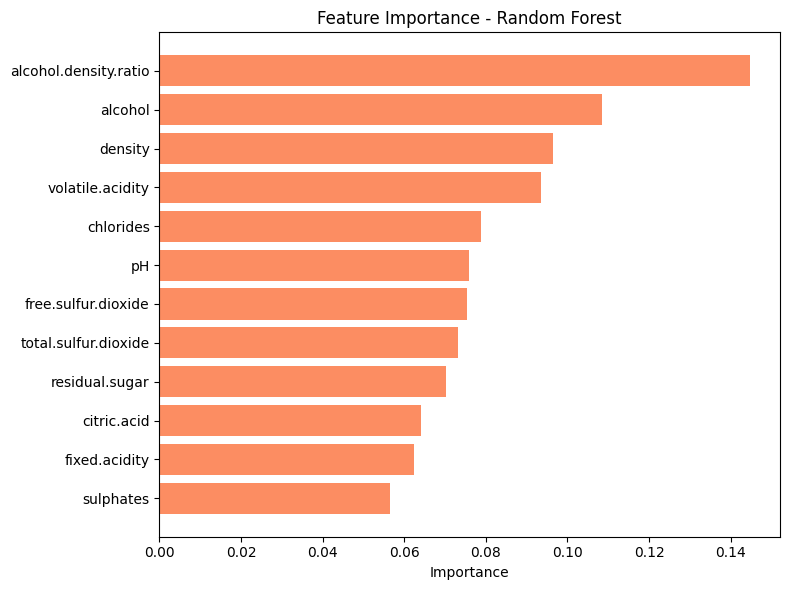

In [118]:
feature_names = X.columns.tolist()
importances = best_model_rf.named_steps['model'].feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='#FC8D62')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance_rf.png')
plt.show()

The results confirm what was observed during the exploratory analysis. Alcohol and alcohol.density.ratio rank as the two most important features, together accounting for over 25% of the model's decisions. Notably, the engineered feature alcohol.density.ratio surpasses alcohol alone, validating the feature engineering decision made during data preparation.

Density and volatile.acidity follow as the next most relevant variables, consistent with the negative correlations identified in the heatmap. The remaining features contribute more moderately, with sulphates showing the lowest individual importance.

## Final Conclusion

This project evaluated multiple classification models to predict wine quality, incorporating a cost-sensitive, business-oriented evaluation framework.

Although Random Forest and XGBoost outperformed Logistic Regression in predictive metrics, the final model selection was based on profit rather than traditional performance alone. Random Forest emerged as the best model, achieving the highest profit by effectively minimizing false positives, the most costly type of error in the defined cost structure.

These results highlight that the model with the best predictive performance is not always the one that delivers the highest business value. Aligning model evaluation with real-world objectives is essential for making effective and impactful decisions in machine learning applications.